# Explainability — Why Does the Model Predict Churn?

A model that predicts churn without explaining *why* isn't actionable — a retention team can't act on a probability alone. This notebook uses SHAP (SHapley Additive exPlanations) to explain the tuned Random Forest from notebook 03, both globally (which features matter overall) and locally (why a specific customer was flagged). Logic lives in `src/explainability.py`.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.train import load_features, split_data
from src.explainability import load_pipeline, transform_features, compute_shap_values, top_features_by_shap

FIGURES_DIR = "../reports/figures"

df = load_features("../data/processed/telco_features.csv")
X_train, X_test, y_train, y_test = split_data(df)

pipeline = load_pipeline("../models/best_model.joblib")
X_test_transformed = transform_features(pipeline, X_test)
print(f"Test set: {X_test_transformed.shape}")

Test set: (1409, 29)


In [2]:
shap_values = compute_shap_values(pipeline, X_test_transformed)
print(f"SHAP values shape: {shap_values.values.shape}")

# 3rd dimension is per-class; slice to the positive (churn) class for all
# plots below, since that's the outcome we actually care about explaining.
shap_values_churn = shap_values[:, :, 1]

SHAP values shape: (1409, 29, 2)


## Global Explainability — What Matters Overall?

Mean absolute SHAP value ranks features by their average impact on the model's churn predictions, regardless of direction. This is a direct, model-native alternative to the mutual information ranking from notebook 02 — comparing the two is a useful sanity check.

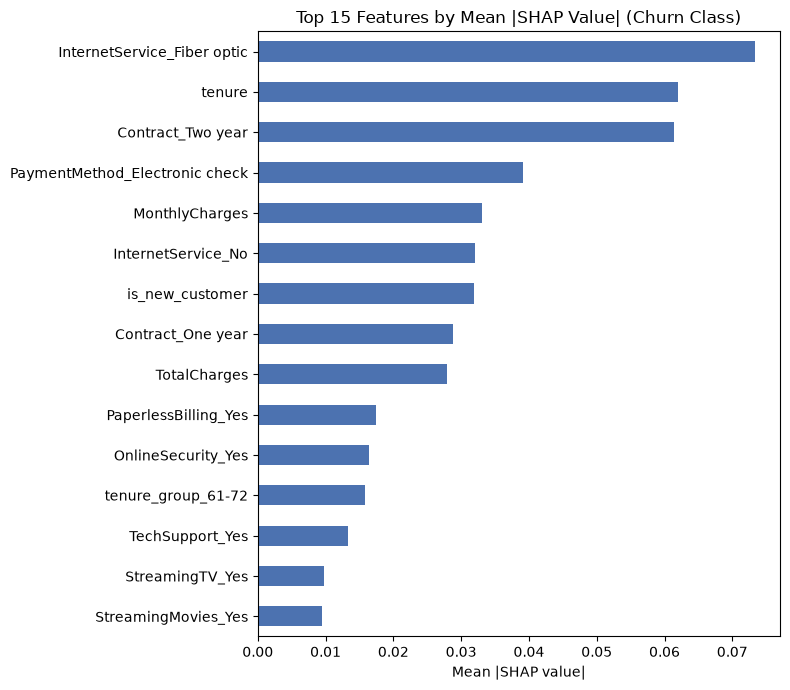

InternetService_Fiber optic       0.073367
tenure                            0.061961
Contract_Two year                 0.061403
PaymentMethod_Electronic check    0.039083
MonthlyCharges                    0.033108
InternetService_No                0.032012
is_new_customer                   0.031851
Contract_One year                 0.028760
TotalCharges                      0.027849
PaperlessBilling_Yes              0.017464
OnlineSecurity_Yes                0.016333
tenure_group_61-72                0.015885
TechSupport_Yes                   0.013365
StreamingTV_Yes                   0.009748
StreamingMovies_Yes               0.009513
dtype: float64

In [3]:
top_features = top_features_by_shap(shap_values, n=15)

fig, ax = plt.subplots(figsize=(8, 7))
top_features.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 Features by Mean |SHAP Value| (Churn Class)")
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_feature_importance.png", dpi=150)
plt.show()

top_features

## Direction of Effect — Beeswarm Plot

The bar chart above shows magnitude but not direction. The beeswarm plot shows both: each dot is one customer, its position shows whether that feature pushed the prediction toward churn (right) or away from it (left), and color shows whether the feature's value was high or low for that customer.

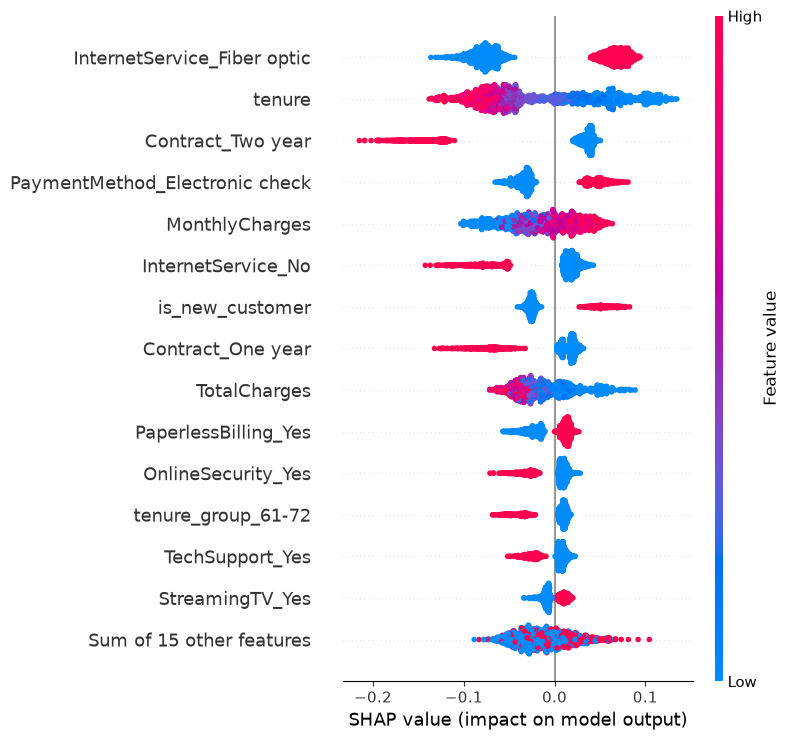

In [4]:
shap.plots.beeswarm(shap_values_churn, max_display=15, show=False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## Local Explainability — Individual Predictions

Global importance tells a data scientist what matters on average. A retention agent needs to know why *this specific customer* was flagged. Below: the highest-risk customer in the test set, the lowest-risk customer, and — most instructively — a customer the model got wrong (a false negative), to see what the model missed.

In [5]:
probs = pipeline.predict_proba(X_test)[:, 1]
preds = pipeline.predict(X_test)

high_risk_idx = int(np.argmax(probs))
low_risk_idx = int(np.argmin(probs))

false_negative_mask = (y_test.values == 1) & (preds == 0)
fn_indices = np.where(false_negative_mask)[0]
fn_idx = int(fn_indices[0]) if len(fn_indices) > 0 else None

print(f"Highest risk — predicted churn prob: {probs[high_risk_idx]:.3f}, actual: {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Retained'}")
print(f"Lowest risk  — predicted churn prob: {probs[low_risk_idx]:.3f}, actual: {'Churned' if y_test.iloc[low_risk_idx] == 1 else 'Retained'}")
if fn_idx is not None:
    print(f"False negative — predicted churn prob: {probs[fn_idx]:.3f}, actual: Churned (missed by the model)")

Highest risk — predicted churn prob: 0.964, actual: Churned
Lowest risk  — predicted churn prob: 0.001, actual: Retained
False negative — predicted churn prob: 0.214, actual: Churned (missed by the model)


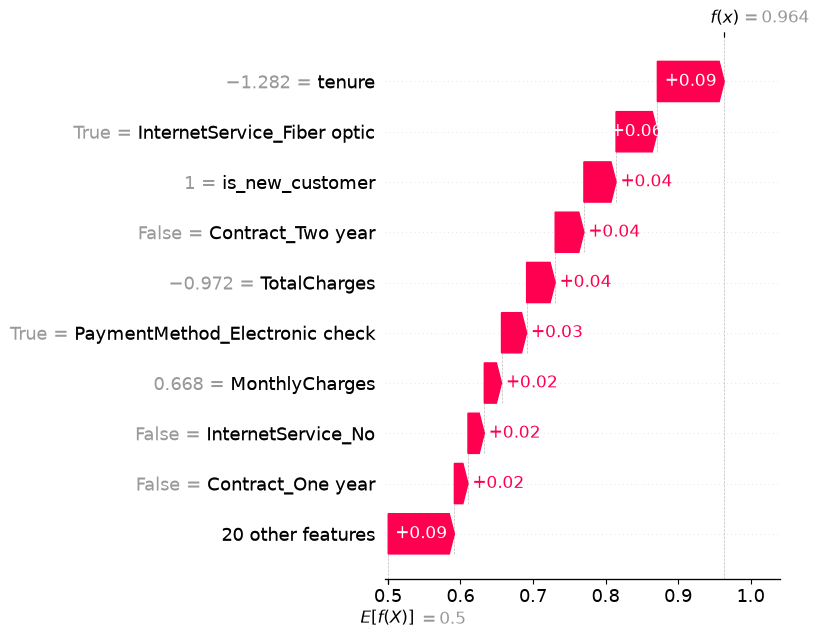

In [6]:
shap.plots.waterfall(shap_values_churn[high_risk_idx], show=False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_waterfall_high_risk.png", dpi=150, bbox_inches="tight")
plt.show()

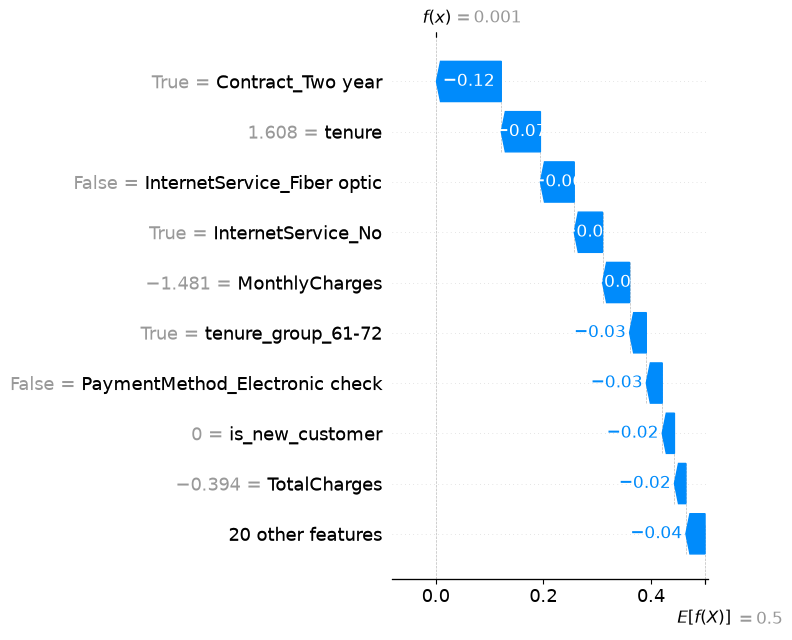

In [7]:
shap.plots.waterfall(shap_values_churn[low_risk_idx], show=False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_waterfall_low_risk.png", dpi=150, bbox_inches="tight")
plt.show()

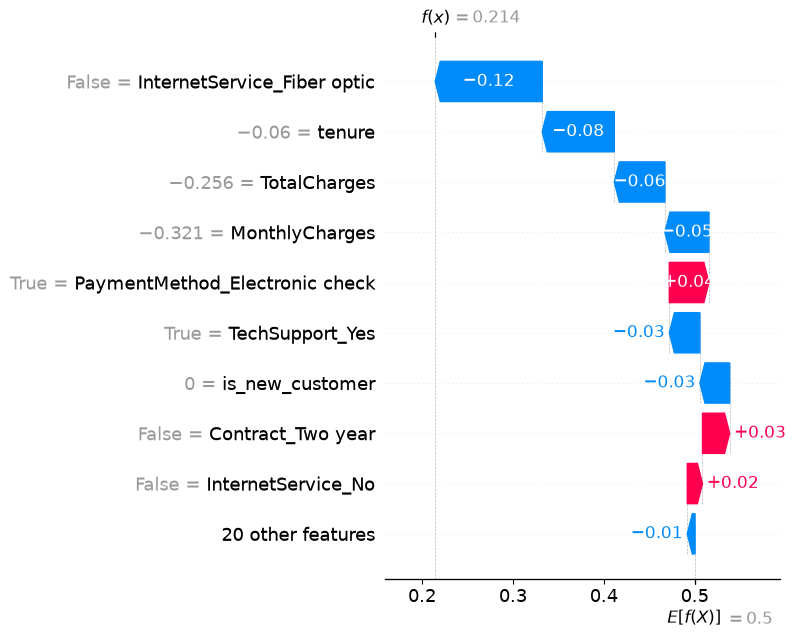

In [8]:
if fn_idx is not None:
    shap.plots.waterfall(shap_values_churn[fn_idx], show=False)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/shap_waterfall_false_negative.png", dpi=150, bbox_inches="tight")
    plt.show()

## Key Findings

- **SHAP's global ranking closely matches the mutual information ranking from notebook 02**: `InternetService_Fiber optic`, `tenure`, `Contract_Two year`, `PaymentMethod_Electronic check`, and `MonthlyCharges` top both independent methods. Two different techniques — one purely statistical (mutual information), one model-native (SHAP on the trained Random Forest) — agreeing on the same top drivers is a strong signal that these effects are real, not an artifact of one particular method.
- **Direction of effect confirms the EDA hypotheses with precision**: the beeswarm plot shows having fiber optic internet, being a new customer, and paying by electronic check each push predictions *toward* churn, while having a two-year contract or no internet service pushes predictions *away* from churn — exactly the direction EDA suggested, now quantified per-customer rather than just as a group-level rate.
- **Individual explanations are directly actionable**: the highest-risk customer in the test set (predicted churn probability 0.964, correctly identified) is explained by short tenure, fiber optic service, new-customer status, no long-term contract, and electronic check payment — a retention agent reading this waterfall chart knows exactly what to address (e.g., offer a contract upgrade) rather than just seeing a risk score.
- **The false negative example is the most honest finding**: a customer with predicted churn probability of only 0.214 churned anyway. Nearly every feature pointed toward retention (DSL not fiber, moderate tenure, has tech support, not a new customer) — electronic check payment was the only signal pointing toward churn, and it wasn't enough to outweigh the rest. This is a legitimate model limitation, not a bug: the available features don't capture things like a specific bad support interaction or a competitor's offer, which plausibly explain real-world churn the model can't see.
- **Practical implication for deployment**: SHAP waterfall explanations are exactly what should power the "why is this customer at risk" view in the Streamlit app — a probability alone isn't useful to a retention team, but a ranked list of contributing factors is.
